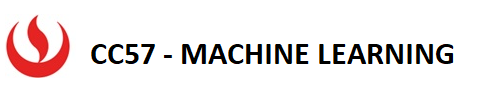

## **ACTIVIDAD #2:** E-COMMERCE AMAZON LIBROS - ANALISIS ESTADISTICO

###**1. DESCRIPCION**

**Amazon.com Inc.** es una tienda de comercio electrónico estadounidense que ofrece una amplia gama de productos, incluyendo libros, música, películas, y computadoras. También ofrece servicios basados en la web, fabrica dispositivos electrónicos tales como Kindle y tabletas, y ofrece servicios de auto-publicación. (Fuente: https://www.bnamericas.com/es/perfil-empresa/amazoncom-inc#:~:text=Amazon.com%20Inc.,ofrece%20servicios%20de%20auto%2Dpublicaci%C3%B3n)

### **2. OBJETIVO**

Realizar un análisis EDA a partir de los datos proporcionados y calcular/visualizar sus principales estadísticas.

####**3. ANALISIS EXPLORATORIO DE LOS DATOS**

El dataset a analizar contiene datos de libros vendidos en Amazon, tanto en formato digital (plaforma Kindle) y fisica.  Cuenta con 133102 observaciones en 16 variables.



#### **3.1. Librerias**

In [48]:
#Incluya las principales librerias a utilizar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as ss
from scipy.stats import chi2_contingency

#### **3.2. Carga de datos**

In [49]:
# Cargar datos de libros_amazon.csv
df = pd.read_csv('libros_amazon.csv')


#### **3.3. Resumen de los datos**


In [50]:
#Info, head y shape
print(f"{df.shape[0]} registros y {df.shape[1]} variables")

133102 registros y 16 variables


In [51]:
df.head()

,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,publishedDate,category_name
0,B00TZE87S4,Adult Children of Emotionally Immature Parents...,Lindsay C. Gibson,Amazon.com Services LLC,https://m.media-amazon.com/images/I/713KZTsaYp...,https://www.amazon.com/dp/B00TZE87S4,4.8,0,9.99,False,6,True,False,False,2015-06-01,Parenting & Relationships
1,B08WCKY8MB,"From Strength to Strength: Finding Success, Ha...",Arthur C. Brooks,Penguin Group (USA) LLC,https://m.media-amazon.com/images/I/A1LZcJFs9E...,https://www.amazon.com/dp/B08WCKY8MB,4.4,0,16.99,False,6,False,False,False,2022-02-15,Parenting & Relationships
2,B09KPS84CJ,Good Inside: A Guide to Becoming the Parent Yo...,Becky Kennedy,HarperCollins Publishers,https://m.media-amazon.com/images/I/71RIWM0sv6...,https://www.amazon.com/dp/B09KPS84CJ,4.8,0,16.99,False,6,False,True,False,2022-09-13,Parenting & Relationships
3,B07S7QPG6J,Everything I Know About Love: A Memoir,Dolly Alderton,HarperCollins Publishers,https://m.media-amazon.com/images/I/71QdQpTiKZ...,https://www.amazon.com/dp/B07S7QPG6J,4.2,0,9.95,True,6,False,True,False,2020-02-25,Parenting & Relationships
4,B00N6PEQV0,The Seven Principles for Making Marriage Work:...,John Gottman,Random House LLC,https://m.media-amazon.com/images/I/813o4WOs+w...,https://www.amazon.com/dp/B00N6PEQV0,4.7,0,13.99,False,6,False,False,False,2015-05-05,Parenting & Relationships


Tipos de varables

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133102 entries, 0 to 133101
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   asin               133102 non-null  object 
 1   title              133102 non-null  object 
 2   author             132677 non-null  object 
 3   soldBy             123869 non-null  object 
 4   imgUrl             133102 non-null  object 
 5   productURL         133102 non-null  object 
 6   stars              133102 non-null  float64
 7   reviews            133102 non-null  int64  
 8   price              133102 non-null  float64
 9   isKindleUnlimited  133102 non-null  bool   
 10  category_id        133102 non-null  int64  
 11  isBestSeller       133102 non-null  bool   
 12  isEditorsPick      133102 non-null  bool   
 13  isGoodReadsChoice  133102 non-null  bool   
 14  publishedDate      84086 non-null   object 
 15  category_name      133102 non-null  object 
dtypes:

In [53]:
# Mostrar detalles estadísticos básicos (solo los calcula a las variables numericas)
q_vars = df.select_dtypes(include=['int64', 'float64']).columns
df[q_vars].describe()

,stars,reviews,price,category_id
count,133102.000000,133102.000000,133102.000000,133102.000000
mean,4.404090,887.375779,15.134127,16.287111
std,0.745646,5104.878777,22.254986,8.416924
min,0.000000,0.000000,0.000000,1.000000
25%,4.400000,0.000000,4.990000,9.000000
50%,4.500000,4.000000,9.990000,16.000000
75%,4.700000,365.000000,14.990000,23.000000
max,5.000000,618227.000000,682.000000,31.000000


In [54]:
# Verificar data faltante en cada columna y duplicados

df.isnull().sum()

asin                     0
title                    0
author                 425
soldBy                9233
imgUrl                   0
productURL               0
stars                    0
reviews                  0
price                    0
isKindleUnlimited        0
category_id              0
isBestSeller             0
isEditorsPick            0
isGoodReadsChoice        0
publishedDate        49016
category_name            0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

Hay nulos pero no duplicados

In [56]:
#Verificar proporciones de valores nulos
df.isnull().mean().sort_values(ascending=False)*100

publishedDate        36.825893
soldBy                6.936785
author                0.319304
title                 0.000000
imgUrl                0.000000
productURL            0.000000
stars                 0.000000
asin                  0.000000
reviews               0.000000
price                 0.000000
category_id           0.000000
isKindleUnlimited     0.000000
isBestSeller          0.000000
isEditorsPick         0.000000
isGoodReadsChoice     0.000000
category_name         0.000000
dtype: float64

In [57]:
h_missing = df.isnull().mean().sort_values(ascending=False)*100
h_missing = h_missing[h_missing > 0]
h_missing = h_missing.reset_index()

In [58]:
h_missing

,index,0
0,publishedDate,36.825893
1,soldBy,6.936785
2,author,0.319304


In [59]:
#Verificar duplicación de registros u observaciones

df['asin'].duplicated().sum() #dado que el asin es el id

np.int64(0)

In [60]:
df['title'].duplicated().sum() 

np.int64(1189)

Hay duplicados de libros, pero no de productos de amazon

###**3.4. Preprocesamiento de los datos**

In [61]:
h_missing

,index,0
0,publishedDate,36.825893
1,soldBy,6.936785
2,author,0.319304


#### Como solucionamos los datos faltantes? Eliminamos todos los datos faltantes?

Tecnicas para tratar los datos faltantes (una para valores numericos y otra para categoricos)

- Autor:  0.32% de los registros son nulos, los eliminaremos
- SoldBy: 6.94% de los registros son nulos, imputaremos con la moda
- publishedDate: 36.83 de los registros son nulos, imputaremos con la moda (revisar tecnica para series temporales) 

In [62]:

df['author'].fillna('Unknown', inplace=True)
df.drop(df[df['author'] == 'Unknown'].index, inplace=True)

# vendido por, inputaremos con la moda 
df['soldBy'] = df['soldBy'].fillna(df['soldBy'].mode()[0])

# publishedDate es un 36% de datos faltantes, se podria inputar por media, mediana
df['publishedDate'] = df['publishedDate'].fillna(df['publishedDate'].mode()[0])


/tmp/ipykernel_32427/137527247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['author'].fillna('Unknown', inplace=True)


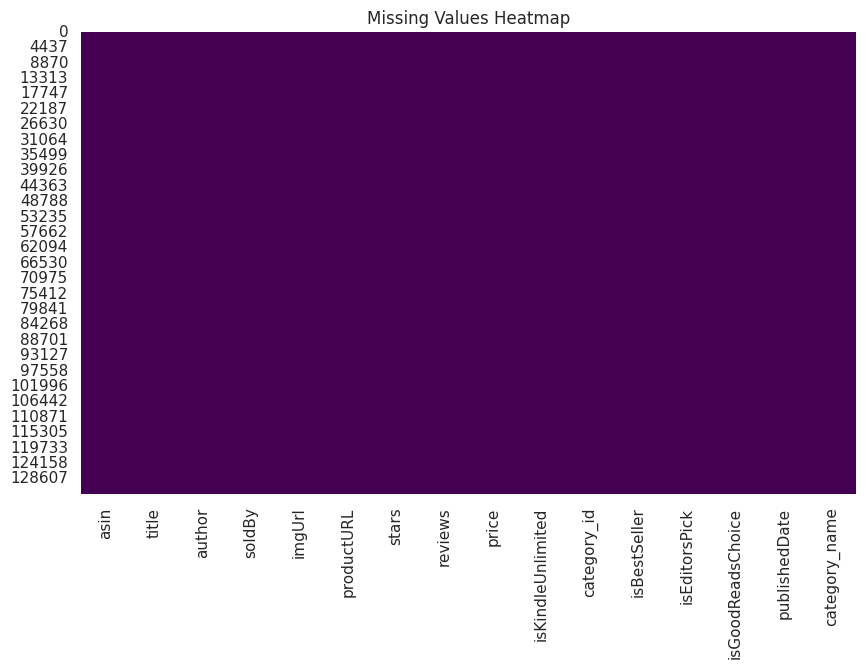

No hay datos faltantes


In [63]:
#Verificamos que no existan datos faltantes
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# usar un ternario 
mv = df.isnull().sum().sum()
if not mv: 
    print("No hay datos faltantes")
else:
    print(f"Hay {mv} datos faltantes") 


In [64]:
#Solucionar duplicidad en los datos (si existen)
nd = df['asin'].duplicated().sum()

if not nd:
    print("No hay duplicados")
else:
    print(f"Hay {nd} duplicados")
    df.drop_duplicates(subset=['asin'], inplace=True)
    print("Duplicados eliminados")

No hay duplicados


In [65]:
#Identificar variables con valores atipicos

df.describe()

,stars,reviews,price,category_id
count,132677.000000,132677.000000,132677.000000,132677.000000
mean,4.404203,886.927591,15.155691,16.279951
std,0.745327,5098.880625,22.283661,8.417464
min,0.000000,0.000000,0.000000,1.000000
25%,4.400000,0.000000,4.990000,9.000000
50%,4.500000,4.000000,9.990000,16.000000
75%,4.700000,366.000000,14.990000,23.000000
max,5.000000,618227.000000,682.000000,31.000000


In [66]:
n_colums = df.describe().columns
n_colums

Index(['stars', 'reviews', 'price', 'category_id'], dtype='object')

### Category_id es una variable categorica

In [95]:
n_colums = n_colums.drop(['category_id'])
n_colums

KeyError: "['category_id'] not found in axis"

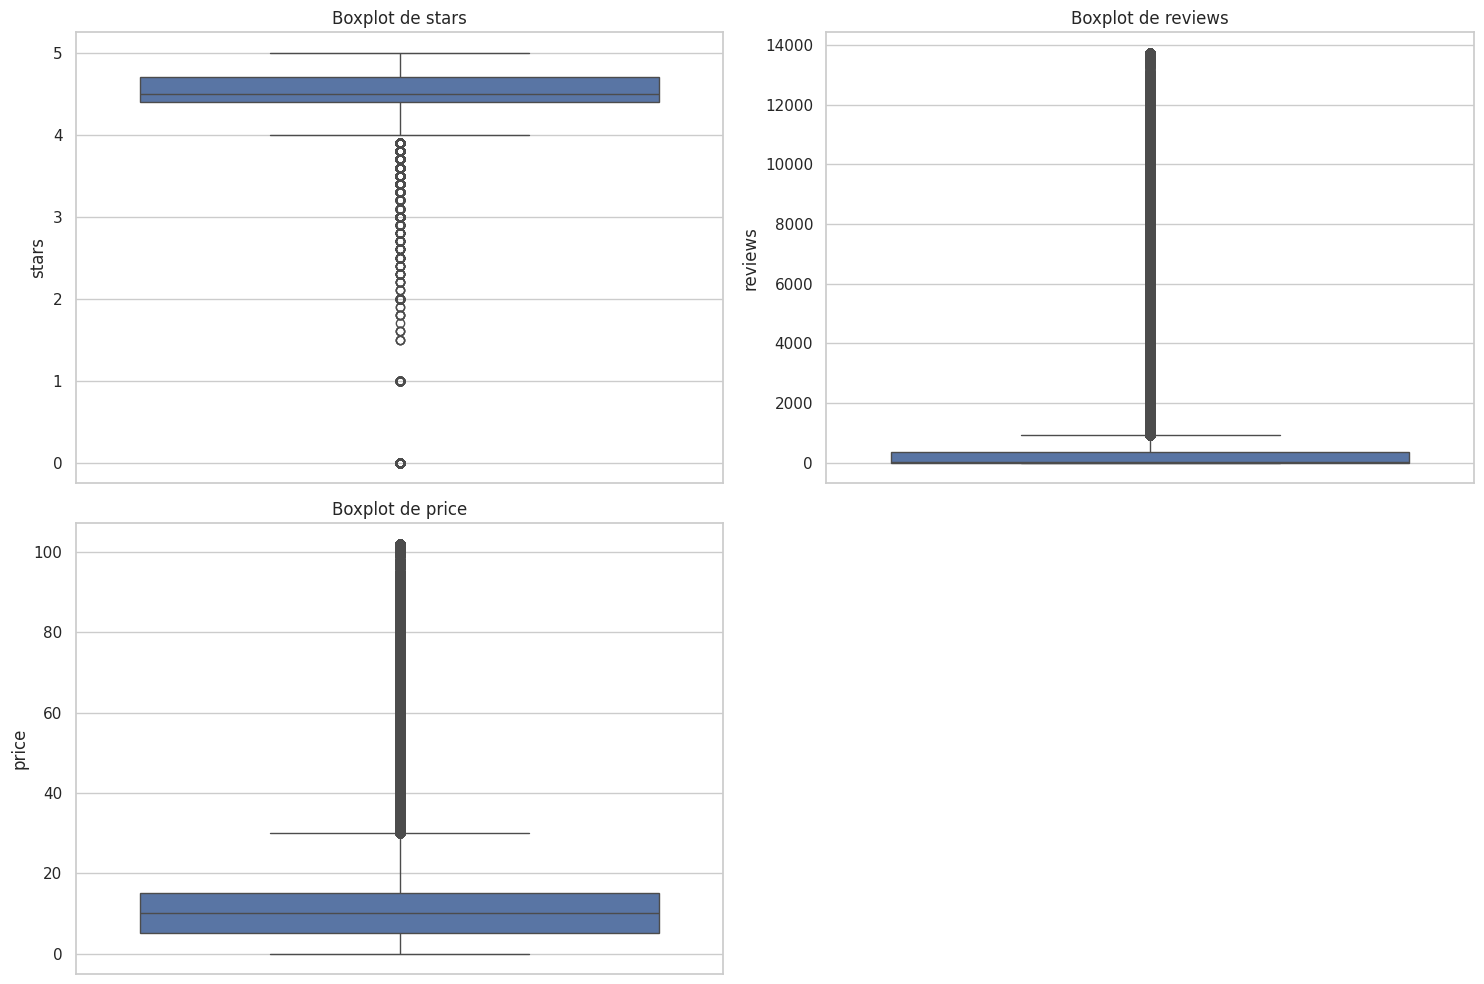

In [94]:
# 2. Exploración visual inicial
plt.figure(figsize=(15, 10))
for i, column in enumerate(n_colums, 1):  
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot de {column}')
plt.tight_layout()
plt.show()

In [96]:
# De existir, eliminar Outliers describiendo que tecnica(s) ha utilizado en cada caso
# category_id, por defincion no deberia tener outliers
# No se visualizan posibles errores de medicion en la variable stars

# price y reviews si podrian contener outliers, usaremos winzorization
def winsorize(series, lower_percentile=0.01, upper_percentile=0.99):
    lower_bound = series.quantile(lower_percentile)
    upper_bound = series.quantile(upper_percentile)
    return np.clip(series, lower_bound, upper_bound)

df[['price', 'reviews']].describe()

,price,reviews
count,132677.000000,132677.000000
mean,14.515771,680.320699
std,17.086884,1971.124132
min,0.000000,0.000000
25%,4.990000,0.000000
50%,9.990000,4.000000
75%,14.990000,366.000000
max,102.000000,13746.680000


In [97]:
df['price'] = winsorize(df['price'])
df['reviews'] = winsorize(df['reviews'])

In [70]:
df[['price', 'reviews']].describe()

,price,reviews
count,132677.000000,132677.000000
mean,14.515771,680.320699
std,17.086884,1971.124132
min,0.000000,0.000000
25%,4.990000,0.000000
50%,9.990000,4.000000
75%,14.990000,366.000000
max,102.000000,13746.680000


In [71]:
# Genere un dataset con los datos preparados'
df.to_csv('libros_amazon_clean.csv', index=False)

A partir de los datos preparados, trabaje las siguientes secciones.

####**4. ESTADISTICA DESCRIPTIVA**

In [98]:
# A partir del dataset preparado, mostrar detalles estadísticos básicos
df_clean = pd.read_csv('libros_amazon_clean.csv')

print(f'Se han cargado {df_clean.shape[0]} registros y {df_clean.shape[1]} variables')


Se han cargado 132677 registros y 16 variables


In [99]:
df_clean.head(3)


,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,publishedDate,category_name
0,B00TZE87S4,Adult Children of Emotionally Immature Parents...,Lindsay C. Gibson,Amazon.com Services LLC,https://m.media-amazon.com/images/I/713KZTsaYp...,https://www.amazon.com/dp/B00TZE87S4,4.8,0.0,9.99,False,6,True,False,False,2015-06-01,Parenting & Relationships
1,B08WCKY8MB,"From Strength to Strength: Finding Success, Ha...",Arthur C. Brooks,Penguin Group (USA) LLC,https://m.media-amazon.com/images/I/A1LZcJFs9E...,https://www.amazon.com/dp/B08WCKY8MB,4.4,0.0,16.99,False,6,False,False,False,2022-02-15,Parenting & Relationships
2,B09KPS84CJ,Good Inside: A Guide to Becoming the Parent Yo...,Becky Kennedy,HarperCollins Publishers,https://m.media-amazon.com/images/I/71RIWM0sv6...,https://www.amazon.com/dp/B09KPS84CJ,4.8,0.0,16.99,False,6,False,True,False,2022-09-13,Parenting & Relationships


In [100]:
df_clean.dtypes

asin                  object
title                 object
author                object
soldBy                object
imgUrl                object
productURL            object
stars                float64
reviews              float64
price                float64
isKindleUnlimited       bool
category_id            int64
isBestSeller            bool
isEditorsPick           bool
isGoodReadsChoice       bool
publishedDate         object
category_name         object
dtype: object

In [101]:
#Identificar y separar variables numéricas y categóricas
num_vars = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_vars = df_clean.select_dtypes(include=['object']).columns
bool_vars = df_clean.select_dtypes(include=['bool']).columns

# el id de categoria es ua varible categorica
num_vars = num_vars.drop(['category_id'])
cat_vars = cat_vars.append(pd.Index(['category_id']))

print("Variables numéricas:", num_vars)
print("Variables categóricas:", cat_vars)
print("Variables booleanas (categorica):", bool_vars)


Variables numéricas: Index(['stars', 'reviews', 'price'], dtype='object')
Variables categóricas: Index(['asin', 'title', 'author', 'soldBy', 'imgUrl', 'productURL',
       'publishedDate', 'category_name', 'category_id'],
      dtype='object')
Variables booleanas (categorica): Index(['isKindleUnlimited', 'isBestSeller', 'isEditorsPick',
       'isGoodReadsChoice'],
      dtype='object')


####**4.1 Análisis Univariado de los Datos**

#### **Diagramas de pares y diagramas de distribución**

In [102]:
# Generar estadísticas descriptivas para columnas numéricas
df_clean[num_vars].describe()


,stars,reviews,price
count,132677.000000,132677.000000,132677.000000
mean,4.404203,680.320699,14.515771
std,0.745327,1971.124132,17.086884
min,0.000000,0.000000,0.000000
25%,4.400000,0.000000,4.990000
50%,4.500000,4.000000,9.990000
75%,4.700000,366.000000,14.990000
max,5.000000,13746.680000,102.000000


In [103]:
# Generar estadísticas descriptivas para columnas categóricas
# Si No hay variables categoricas, considere crear algunas
df_clean[cat_vars].describe(include='all')

,asin,title,author,soldBy,imgUrl,productURL,publishedDate,category_name,category_id
count,132677,132677,132677,132677,132677,132677,132677,132677,132677.000000
unique,132677,131493,72805,49,132488,132677,7155,31,NaN
top,B0BS1KYZB6,Organic Chemistry,James Patterson,Amazon.com Services LLC,https://m.media-amazon.com/images/I/01RmK+J4pJ...,https://www.amazon.com/dp/B0BS1KYZB6,2023-09-12,"Mystery, Thriller & Suspense",NaN
freq,1,8,212,93618,104,1,49027,6245,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.279951
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.417464
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000


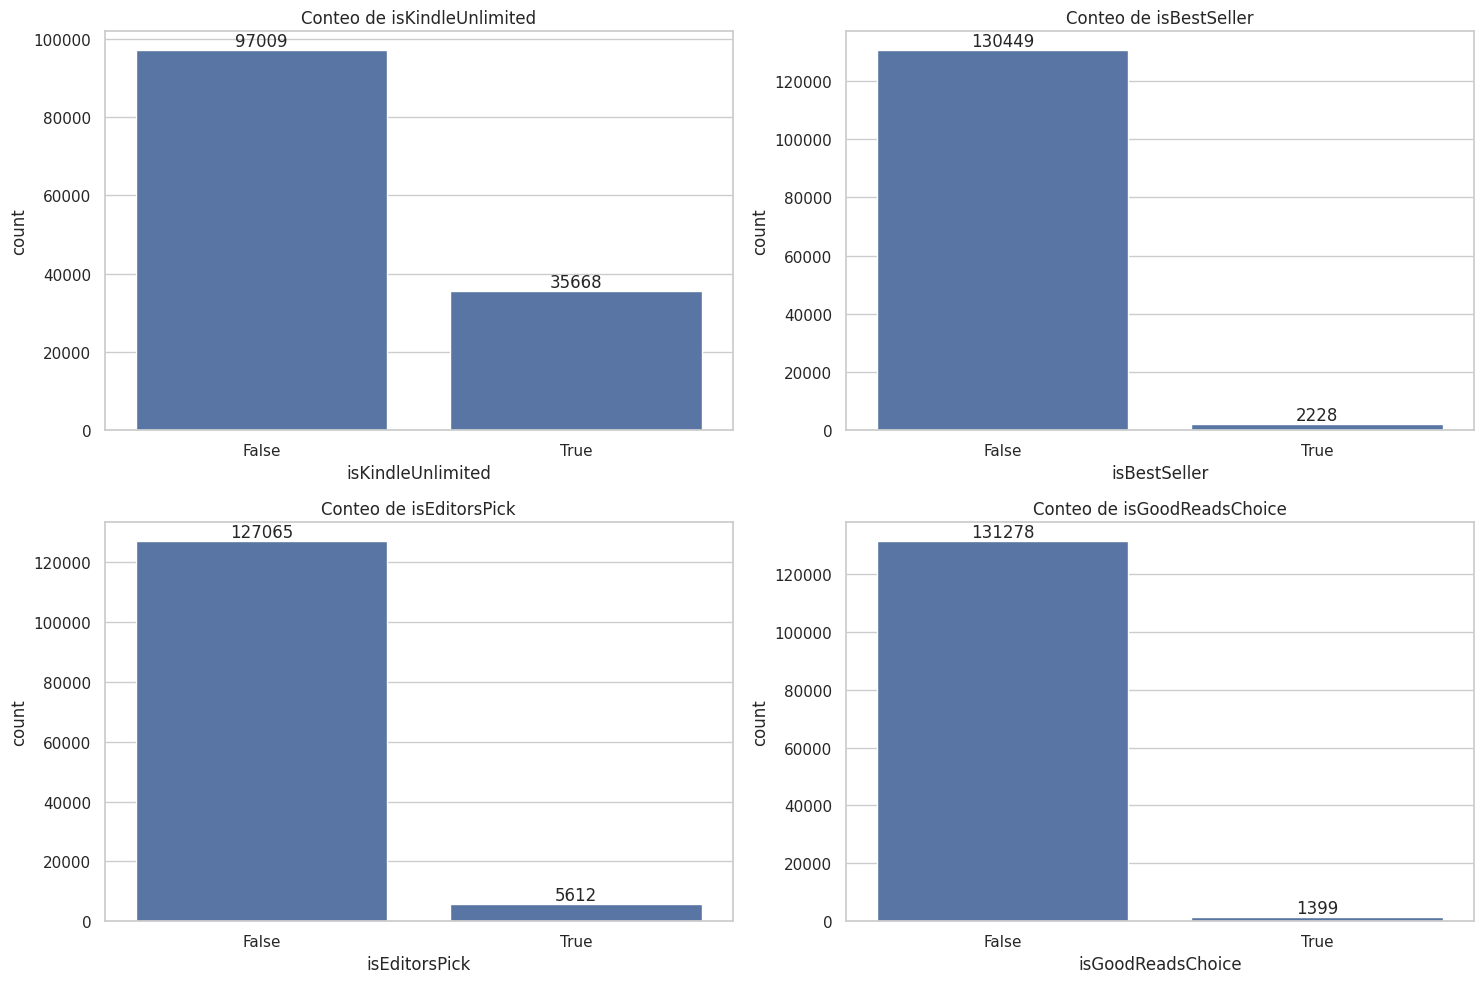

In [78]:
plt.figure(figsize=(15, 10))
df_clean[bool_vars]
for i, c in enumerate(bool_vars, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=c, data=df_clean)
    plt.bar_label(plt.gca().containers[0])
    plt.title(f'Conteo de {c}')
plt.tight_layout()
plt.show()

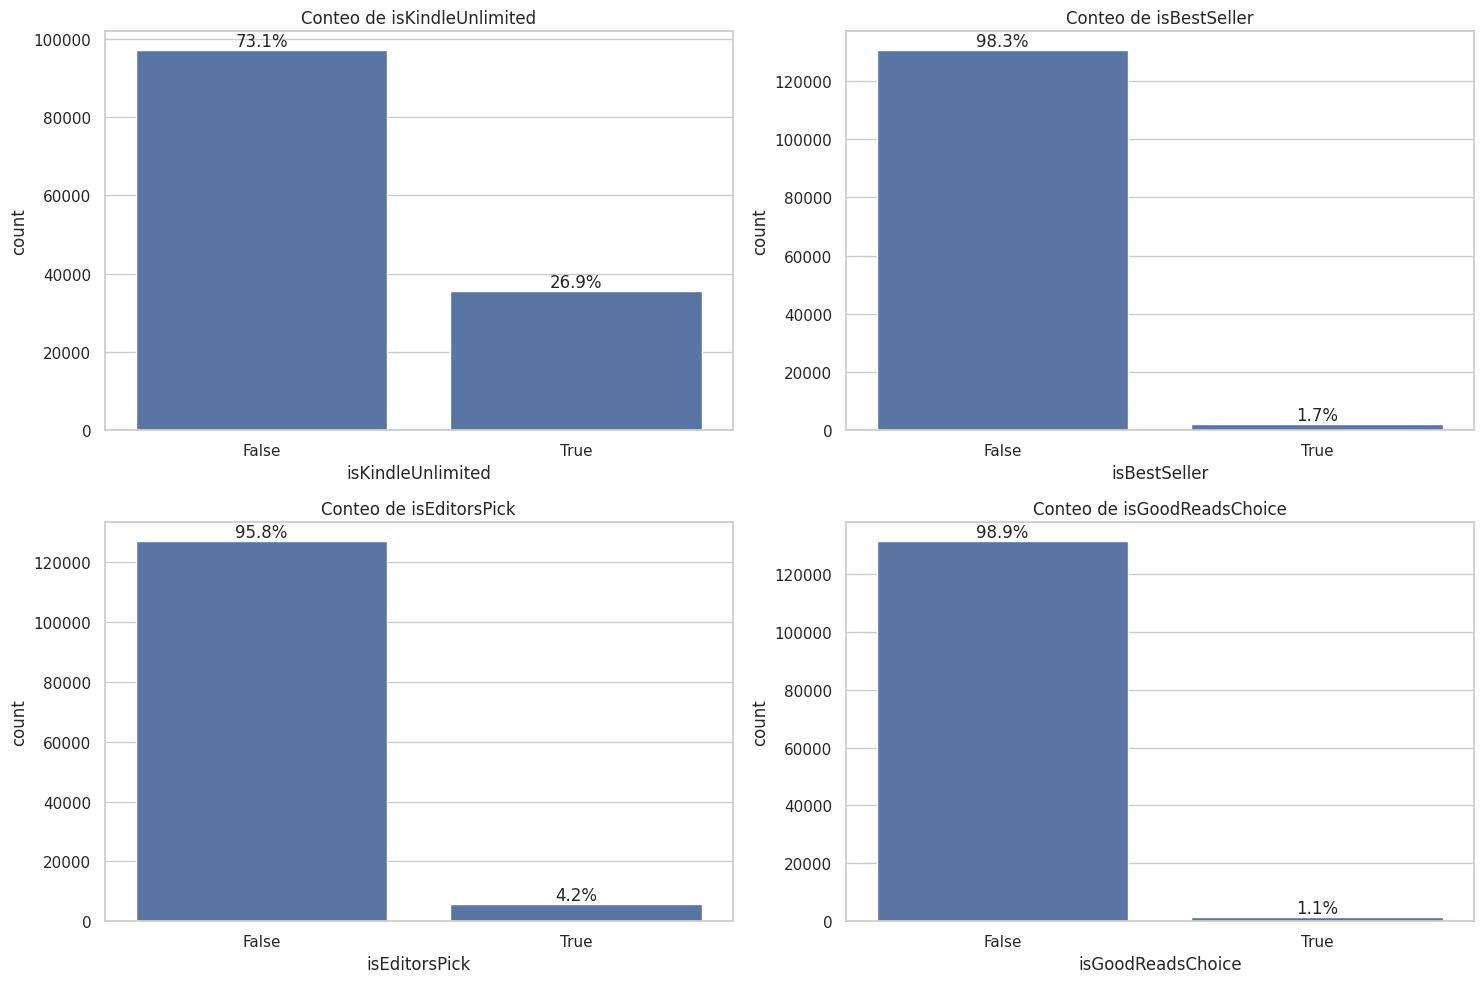

In [104]:
plt.figure(figsize=(15, 10))
sns.set(style="whitegrid")
for i, c in enumerate(bool_vars, 1):
    if i <= 4:  # Asegurarse de no exceder el número de subplots
        plt.subplot(2, 2, i)
        ax = sns.countplot(x=c, data=df_clean)
        
        # Calcular y mostrar porcentajes
        total = len(df_clean)
        for p in ax.patches:
            percentage = f'{100 * p.get_height() / total:.1f}%'
            ax.annotate(percentage, 
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'bottom')
            
        plt.title(f'Conteo de {c}')
plt.tight_layout()
plt.show()


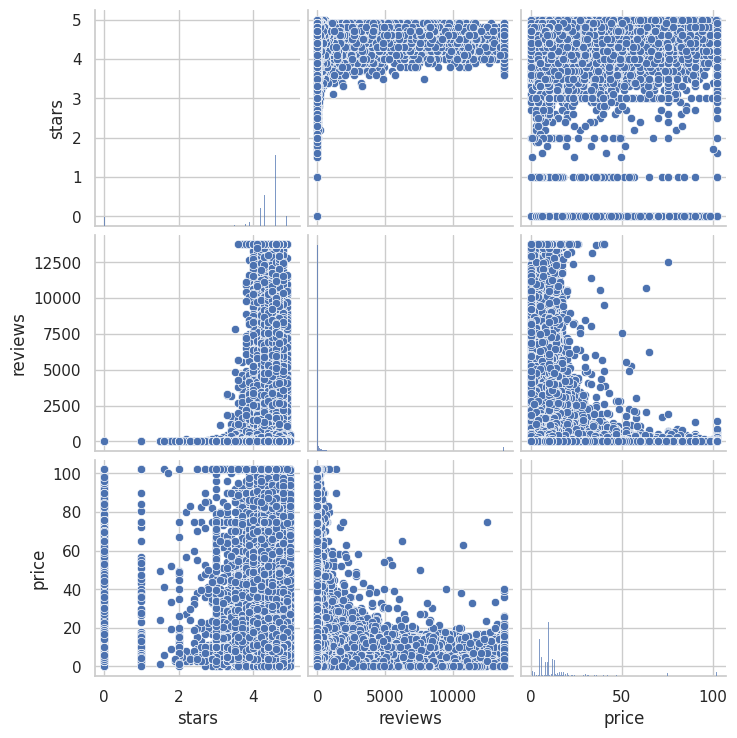

In [80]:
# Creando un diagrama de pares y de distribucion para variables numéricas
sns.pairplot(df_clean[num_vars])

<Figure size 1500x1000 with 0 Axes>

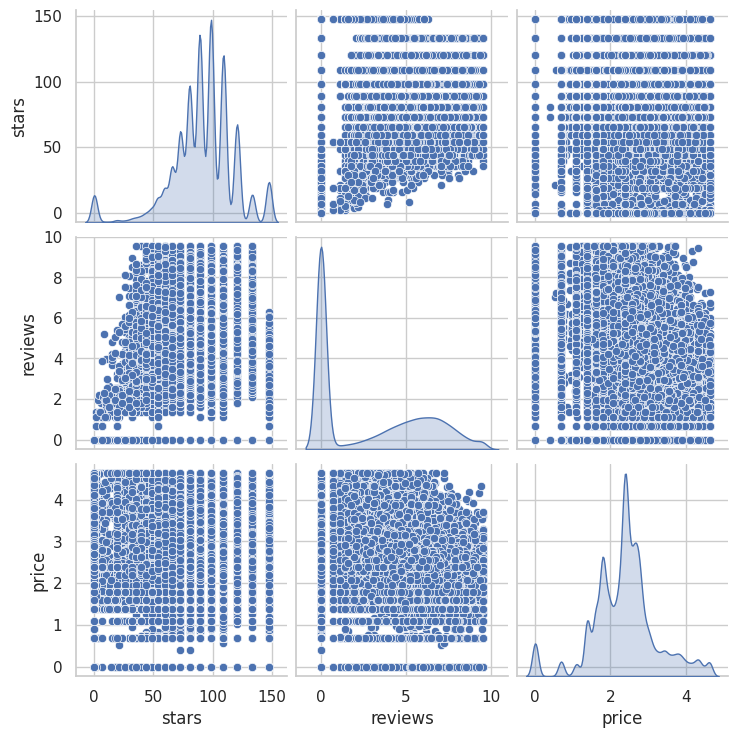

In [105]:
# Utilice algunas de las medidas de dispersion y representelas a traves de diagramas
# Creando un diagrama de pares y de distribucion para variables numéricas

df_normal = df_clean[num_vars].copy()

# Normalizar las variables numéricas
for col in num_vars:
    if df_normal[col].skew() > 0:
        df_normal[col] = np.log1p(df_normal[col])
    elif df_normal[col].skew() < 0:
        df_normal[col] = np.exp(df_normal[col]) - 1
    else:
        df_normal[col] = df_normal[col]
# Graficar el diagrama de pares
plt.figure(figsize=(15, 10))
sns.pairplot(df_normal[num_vars], diag_kind='kde')
plt.show()


####**4.2 Análisis Bivariado de los Datos**

#### **- Correlacion de variables**

In [106]:
# Calcular e imprimir la matriz de correlación para variables numéricas.

correlation_matrix = df_clean[num_vars].corr()
correlation_matrix

,stars,reviews,price
stars,1.000000,0.054612,-0.114258
reviews,0.054612,1.000000,-0.118208
price,-0.114258,-0.118208,1.000000


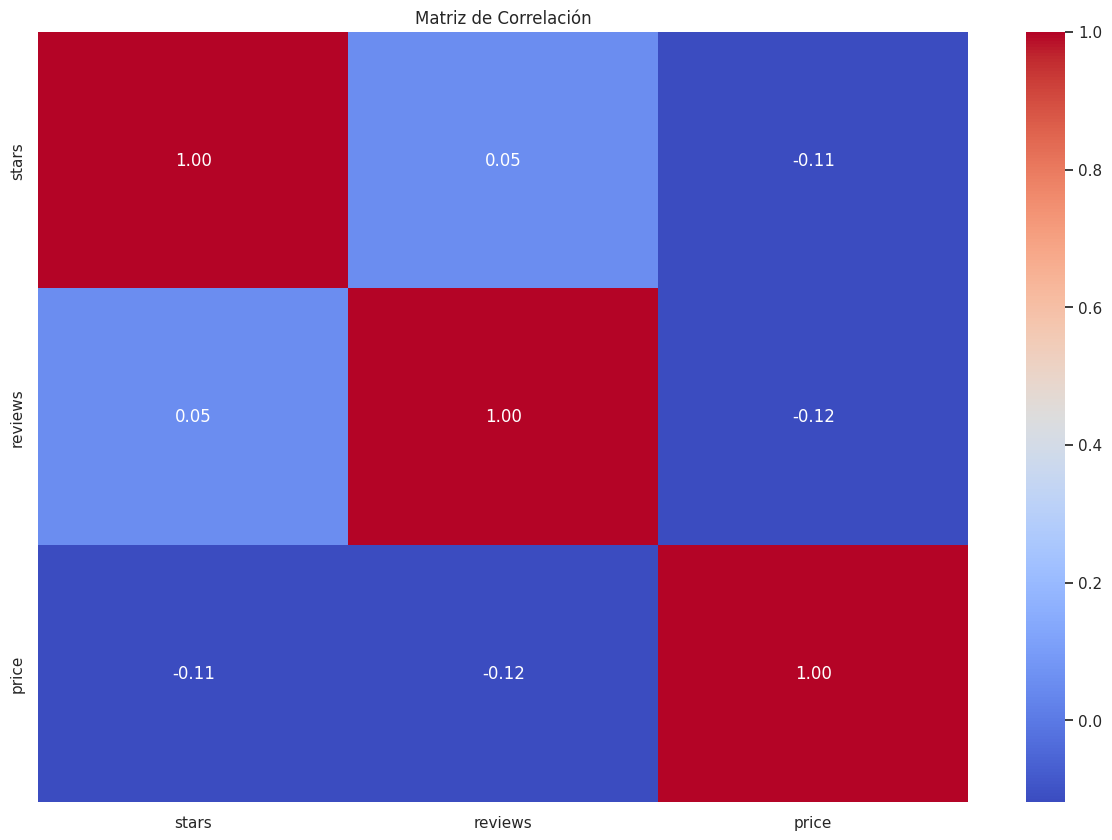

In [107]:
# Visualizar la matriz de correlacion en un mapa de calor
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

La data numerica esta pobremente relacionada linealmente

In [108]:
# Calculo del coeficiente de asimetria y de curtosis. Como los interpreta?
# Coeficiente de asimetría
skewness = df_clean[num_vars].skew()
skewness

stars     -5.006855
reviews    4.746316
price      3.048357
dtype: float64

- Las resenas se concentran notoriamente en valores bajos
- las reviews se concentran notoriamente en valores altos
- el precio se concentra en valores altos

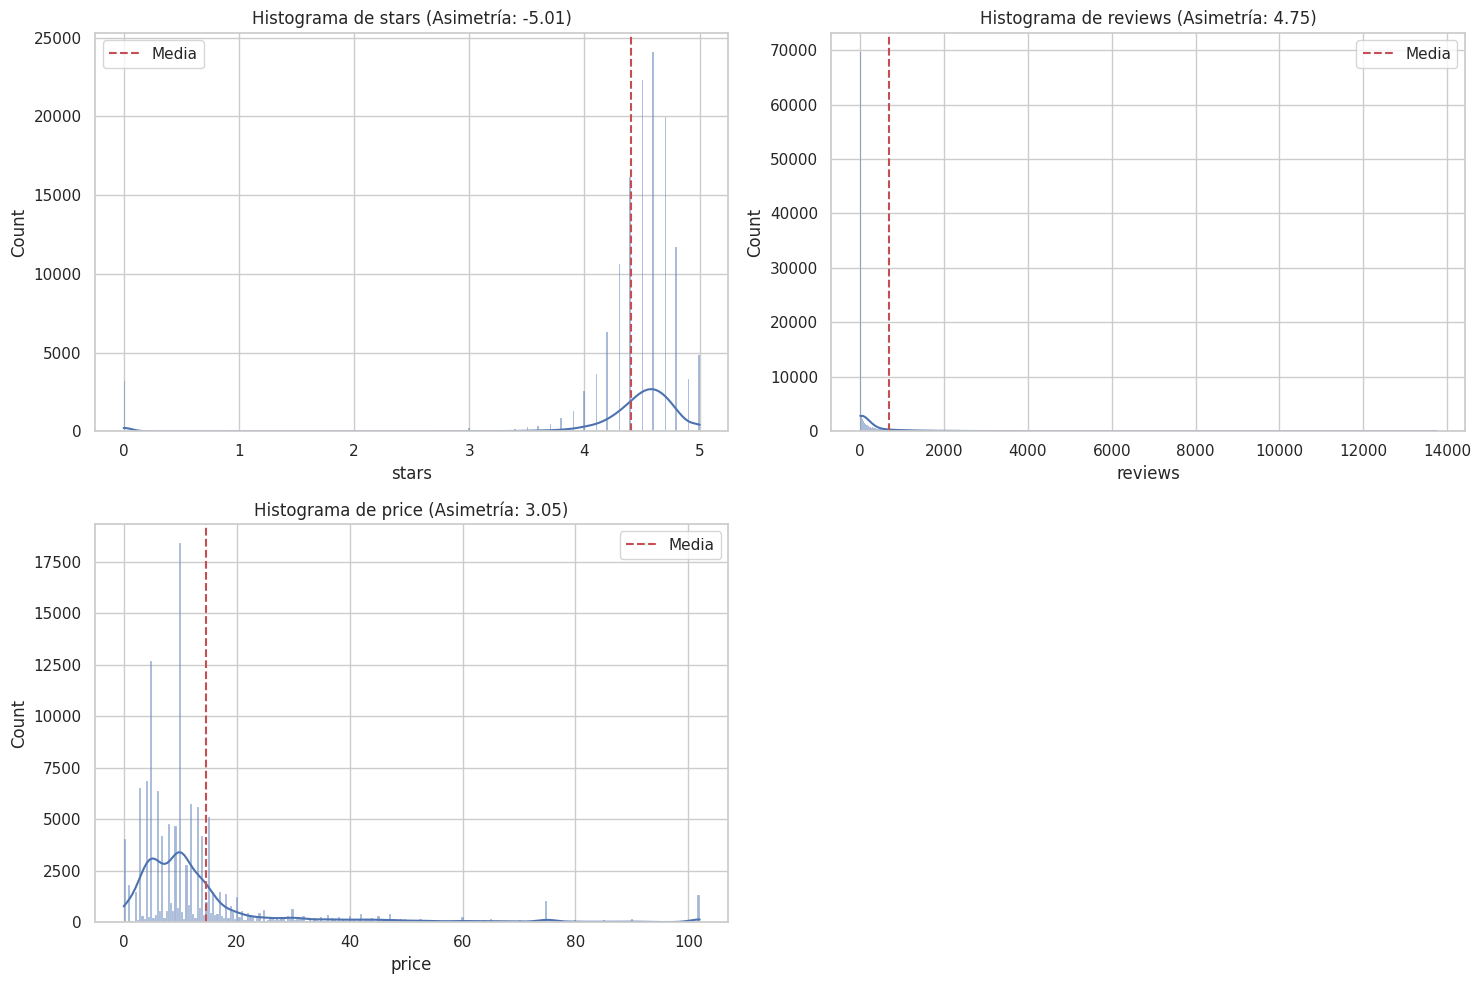

In [109]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(num_vars, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[column], kde=True)
    plt.axvline(df_clean[column].mean(), color='r', linestyle='--', label='Media')
    plt.legend()
    plt.title(f'Histograma de {column} (Asimetría: {skewness[column]:.2f})')
plt.tight_layout()
plt.show()

Por el alto de la curva,Rapidamente hipotetisamos que price, tendra menor curtosis, seguido de stars y finalmente reviews

In [114]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132677 entries, 0 to 132676
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   asin               132677 non-null  object 
 1   title              132677 non-null  object 
 2   author             132677 non-null  object 
 3   soldBy             132677 non-null  object 
 4   imgUrl             132677 non-null  object 
 5   productURL         132677 non-null  object 
 6   stars              132677 non-null  float64
 7   reviews            132677 non-null  float64
 8   price              132677 non-null  float64
 9   isKindleUnlimited  132677 non-null  bool   
 10  category_id        132677 non-null  int64  
 11  isBestSeller       132677 non-null  bool   
 12  isEditorsPick      132677 non-null  bool   
 13  isGoodReadsChoice  132677 non-null  bool   
 14  publishedDate      132677 non-null  object 
 15  category_name      132677 non-null  object 
dtypes:

In [86]:
# curtosis
kurtosis = df_clean[num_vars].kurtosis()
kurtosis

stars      26.564231
reviews    24.932802
price      10.241491
dtype: float64

¿Qué variables son las tienen mayor correlación?

<Axes: >

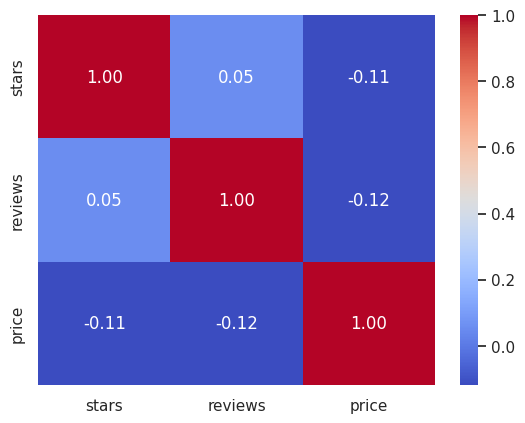

In [87]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

**Respuesta:**

Pues lineal, ninguna todas tienen valores abs inferiores al 0.15

### **4. Visualización de los datos**

In [88]:
bool_vars

Index(['isKindleUnlimited', 'isBestSeller', 'isEditorsPick',
       'isGoodReadsChoice'],
      dtype='object')

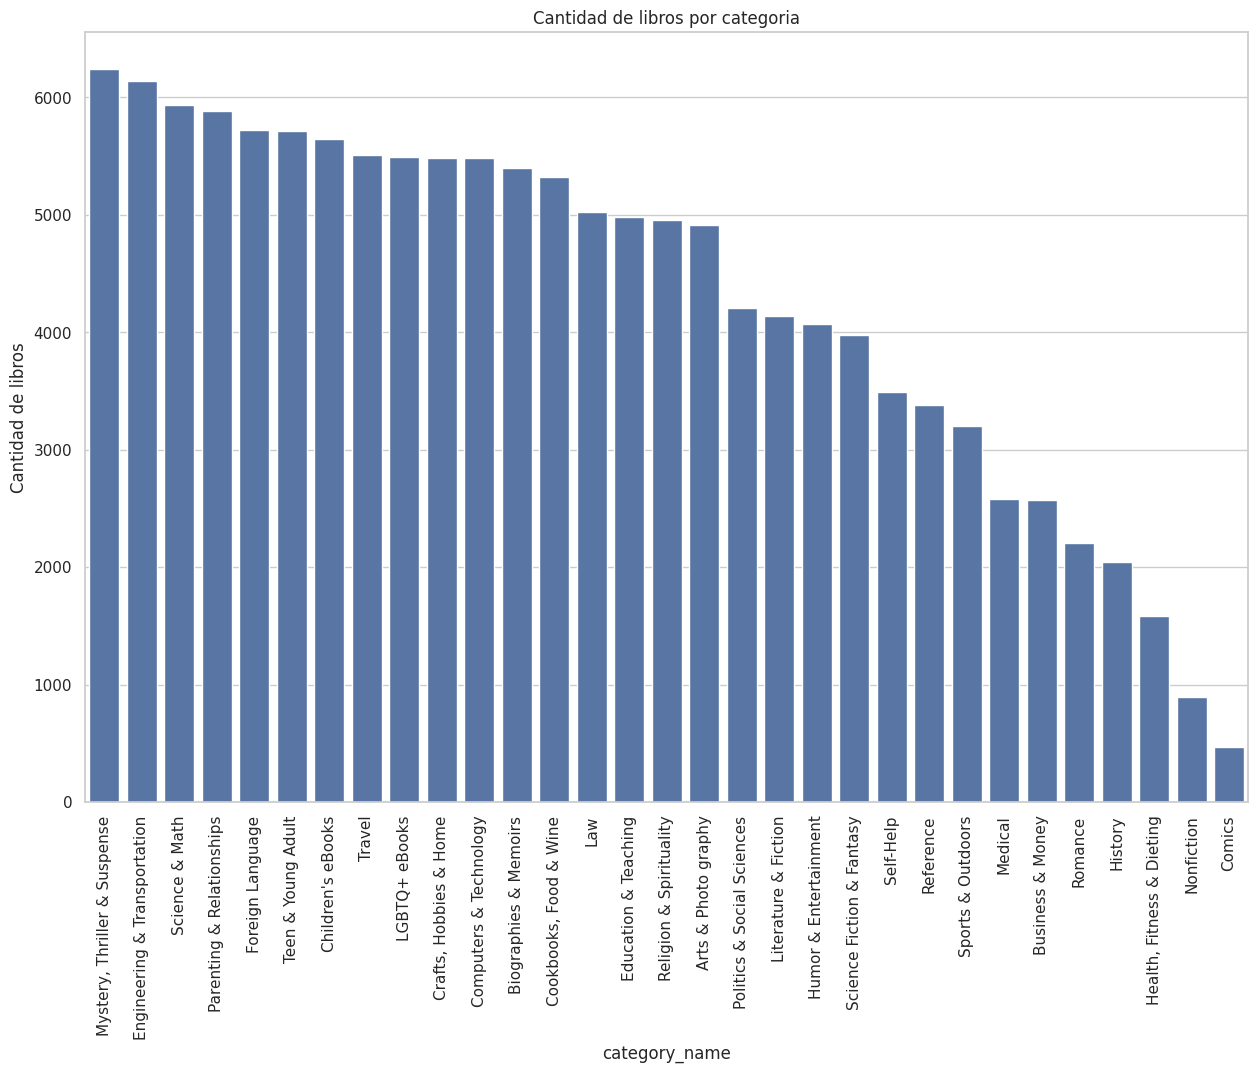

In [111]:
# Cantidad de libros por cada categoria
plt.figure(figsize=(15, 10))
sns.countplot(data=df_clean, x='category_name', order=df_clean['category_name'].value_counts().index)
plt.title('Cantidad de libros por categoria')
plt.xlabel('category_name')
plt.ylabel('Cantidad de libros')
plt.xticks(rotation=90)
plt.show()

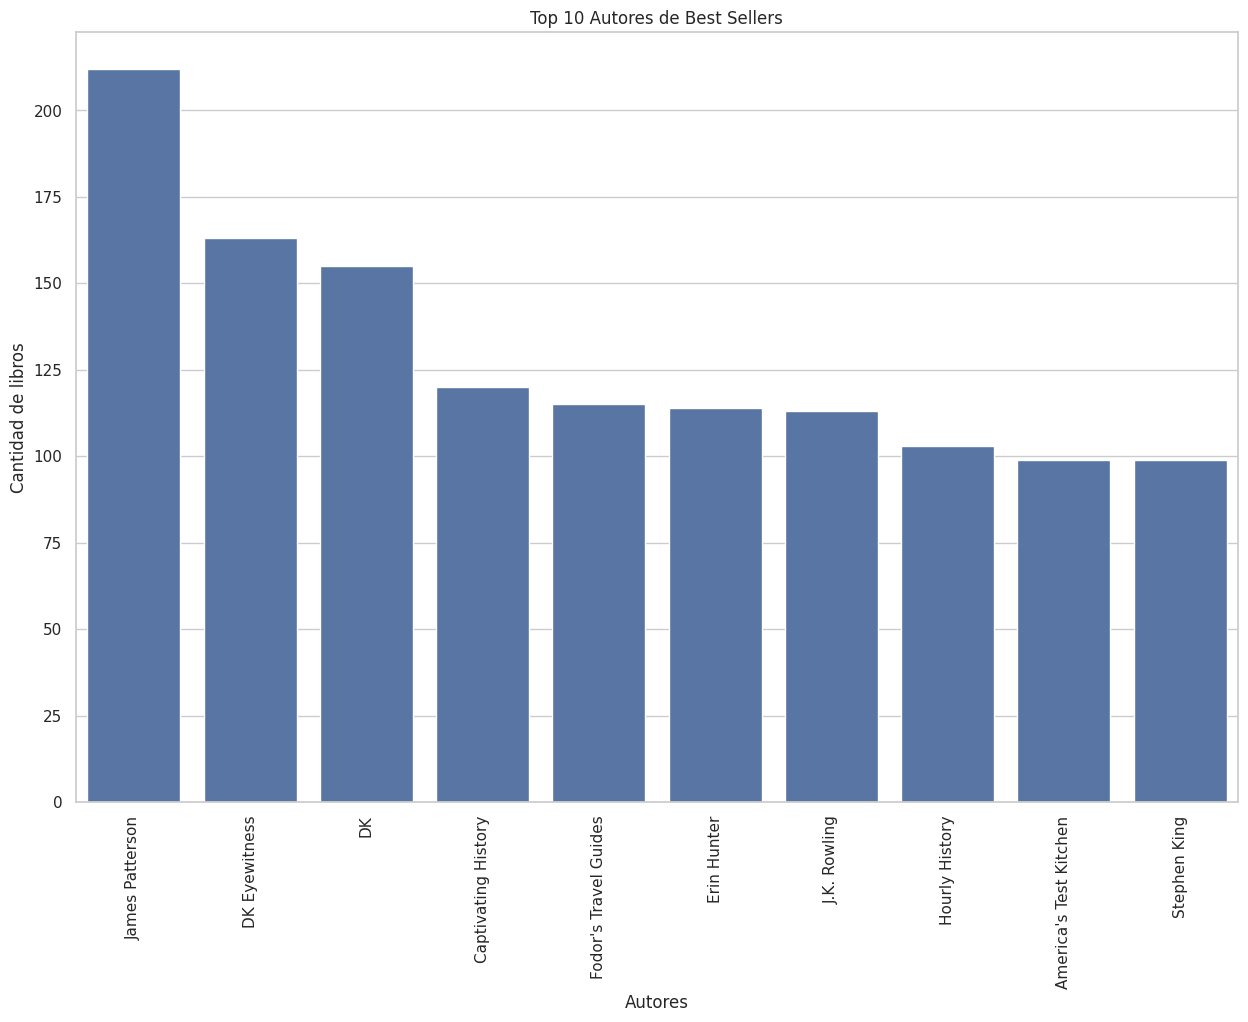

In [123]:
# Autores con mayor cantidad de libros
top_authors = df_clean['author'].value_counts().head(10)
plt.figure(figsize=(15, 10))
sns.barplot(x=top_authors.index, y=top_authors.values)
plt.title('Top 10 Autores de Best Sellers')
plt.xlabel('Autores')
plt.ylabel('Cantidad de libros')
plt.xticks(rotation=90)
plt.show()

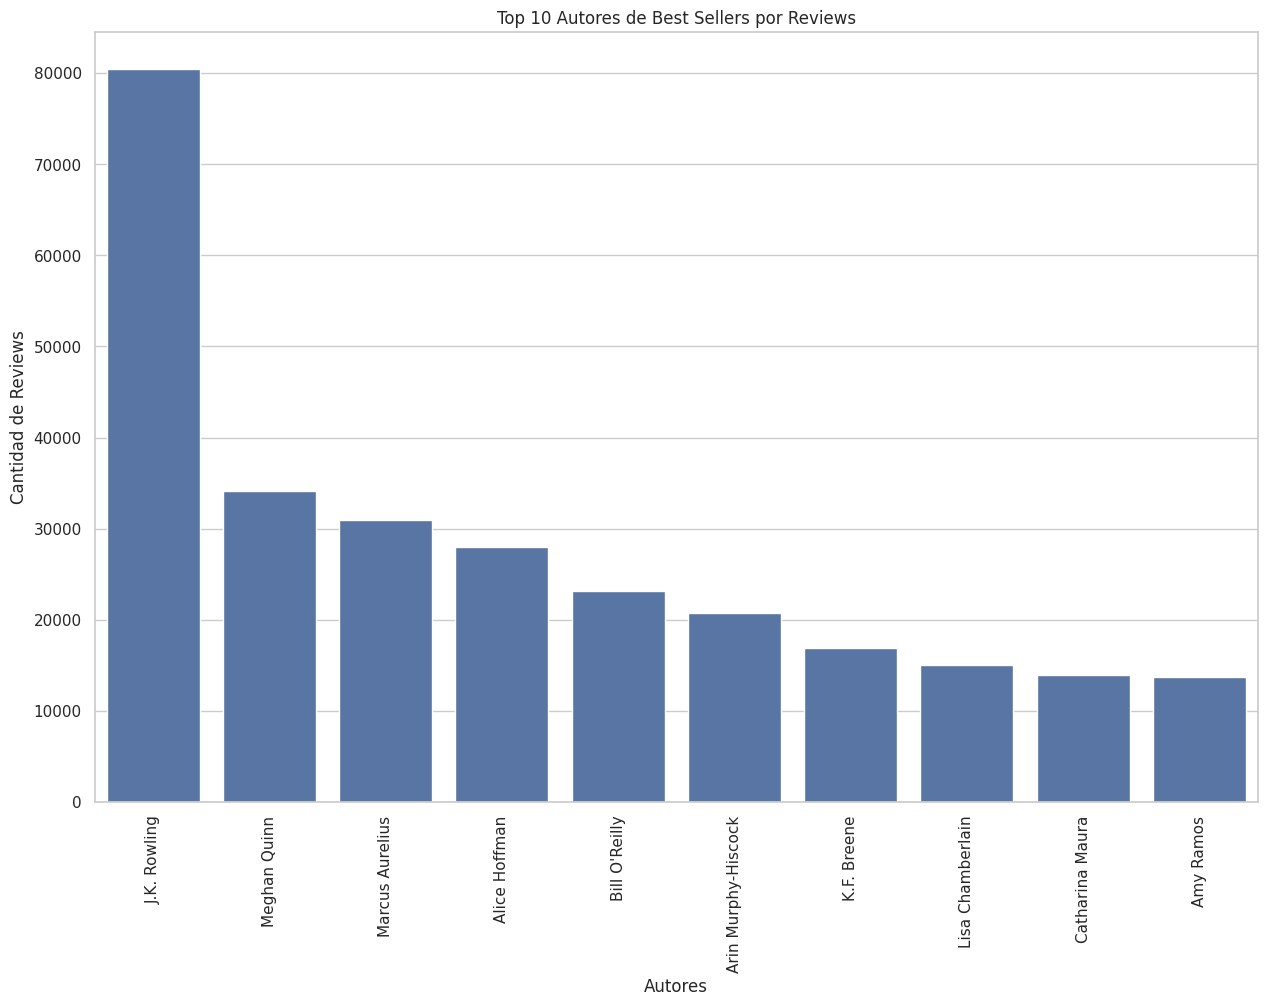

In [120]:
#Top Autores de Best Sellers
df_clean_best = df_clean[df_clean['isBestSeller']]

better_authors = df_clean_best.groupby('author')['reviews'].sum().nlargest(10)
plt.figure(figsize=(15, 10))
sns.barplot(x=better_authors.index, y=better_authors.values)
plt.title('Top 10 Autores de Best Sellers por Reviews')
plt.xlabel('Autores')
plt.ylabel('Cantidad de Reviews')
plt.xticks(rotation=90)
plt.show()




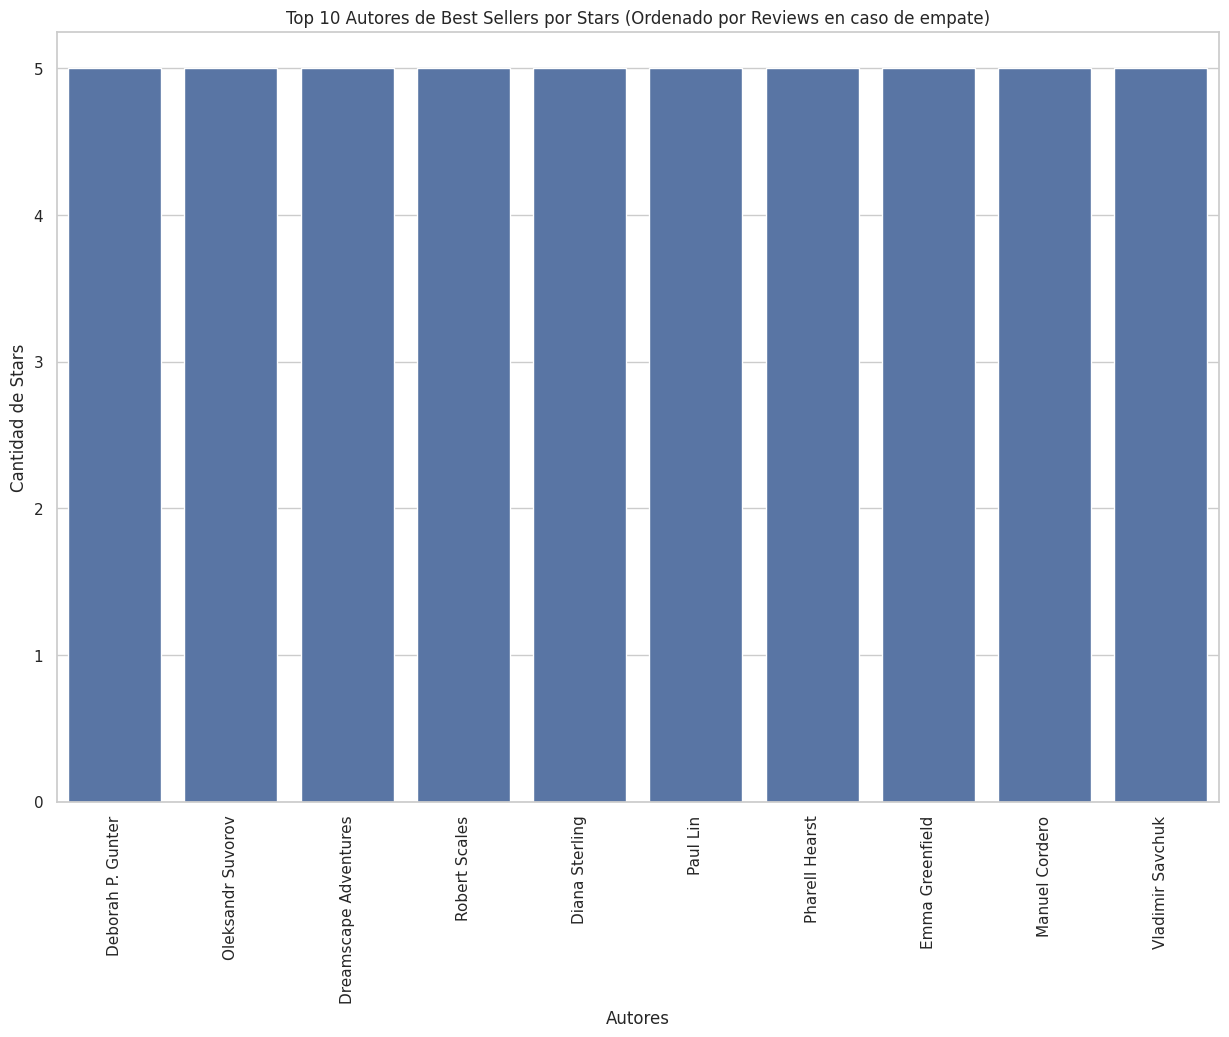

In [121]:
#Ratings for Best Sellers
auth_betsellers = df_clean.groupby('author').agg({'stars': 'mean', 'reviews': 'sum'})
auth_betsellers = auth_betsellers.nlargest(10, ['stars', 'reviews'])

plt.figure(figsize=(15, 10))
sns.barplot(x=auth_betsellers.index, y=auth_betsellers['stars'])
plt.title('Top 10 Autores de Best Sellers por Stars (Ordenado por Reviews en caso de empate)')
plt.xlabel('Autores')
plt.ylabel('Cantidad de Stars')
plt.xticks(rotation=90)
plt.show()

### **5. Observaciones**

**Respuesta:** (liste las principales observaciones o conclusiones observadas luego del análisis)

**Limpieza de datos**
- No hay duplicados, pero si encontramos el mismo libro con diferentes codigos asin (posiblmente diferentes ediciones)
- Datos faltantesen `fecha de puiblicacion`, `vendido por` y `autor`
- Se imputaron los datos faltantes de `vendido por` y `fecha de publicacion` con la moda, se elimaron 0.32% de los registros, correspondientes a missing values en `autor`
- Se eliminaron outliers en `price` y `reviews` utilizando winsorization

**Estadistica Descriptiva**
- No es usual que un libro tenga menos de 4.4 estrellas (25% de los libros cuentan con menos de 4.4 estrellas)
- El 50% de los libros tienen menos de 4 reviews, y el más popular tiene aproximadamente 13,736 considerado outlier
- La mayoria de libros (75%) cuestan al menos de 14.99.

**Analisis univariado** 
- Los libros que no cuentan con kindle(73.1%) son casi 3 veces mas que los que si cuentan (26.9&)
- Los bestSellers representan aproximadamente el 1.7% de los libros
- Lo libros que son buena opcion para leer(isGoodReadsChoice) representan un 1.1% del total

**Analisis bivariado**
- La data se encuentra pobremente correlacionada (lineal) en stars, reviews y price (valores inferiores al 15% de correlacion lineal)
- Los valores de stars se concentrarn en valores altos 
- Lo valores de reviews se concentran en valores bajos
- Los valores de price se concentran en valores bajos




**Vizualizacion de datos**
La categoria con más libros es Misterio, thriller y suspenso. Comics es la categoria con menos libros representando casi 1/10 de Misterio.

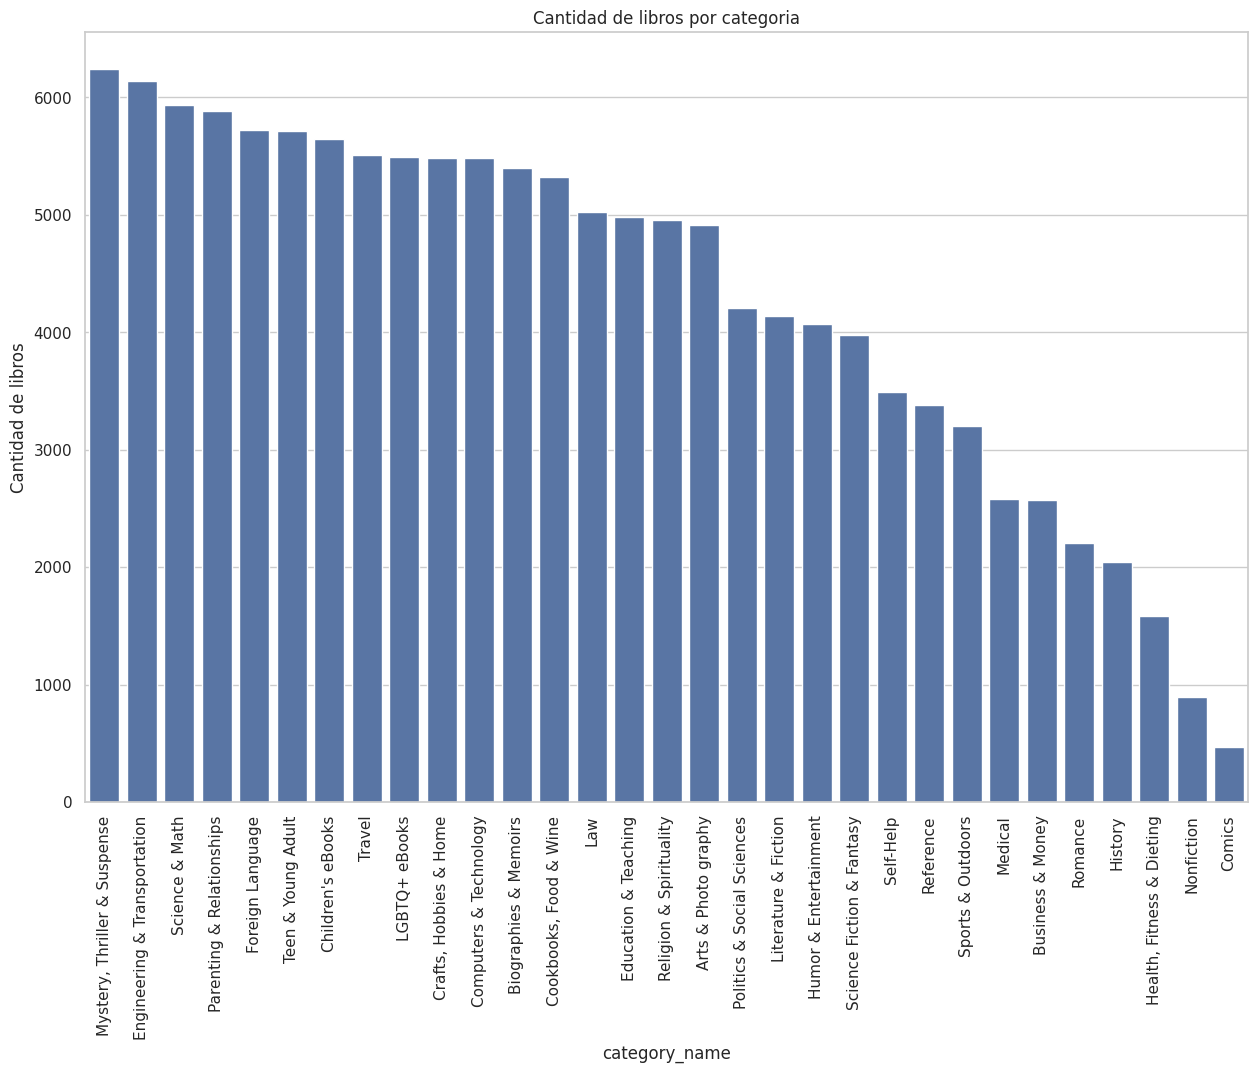

Los autores con mas libros son James Patterson, DK Eywithnes y DK. Siendo que Dorling Kindersley (DK), es una editorial y DK eywithnes es una serie de libros publicados por ella, el autor mas comun es esta editorial. Seria conveniene separar las editoriales de los autores(persona)

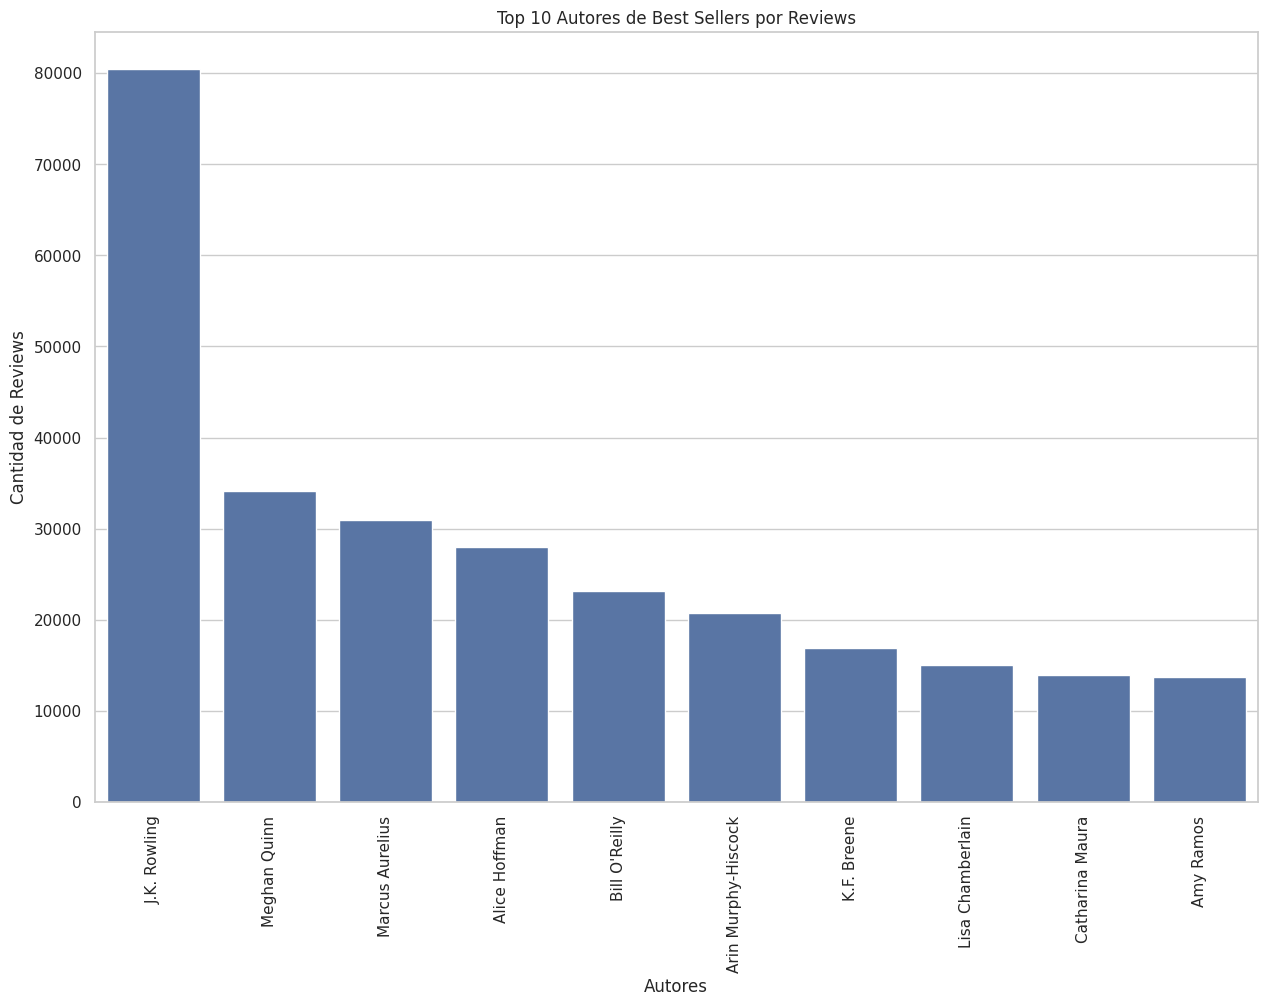

En este segundo grafico de ordenacion de libros ya vemos personas, donde JK. Rowling destaca ampliamente
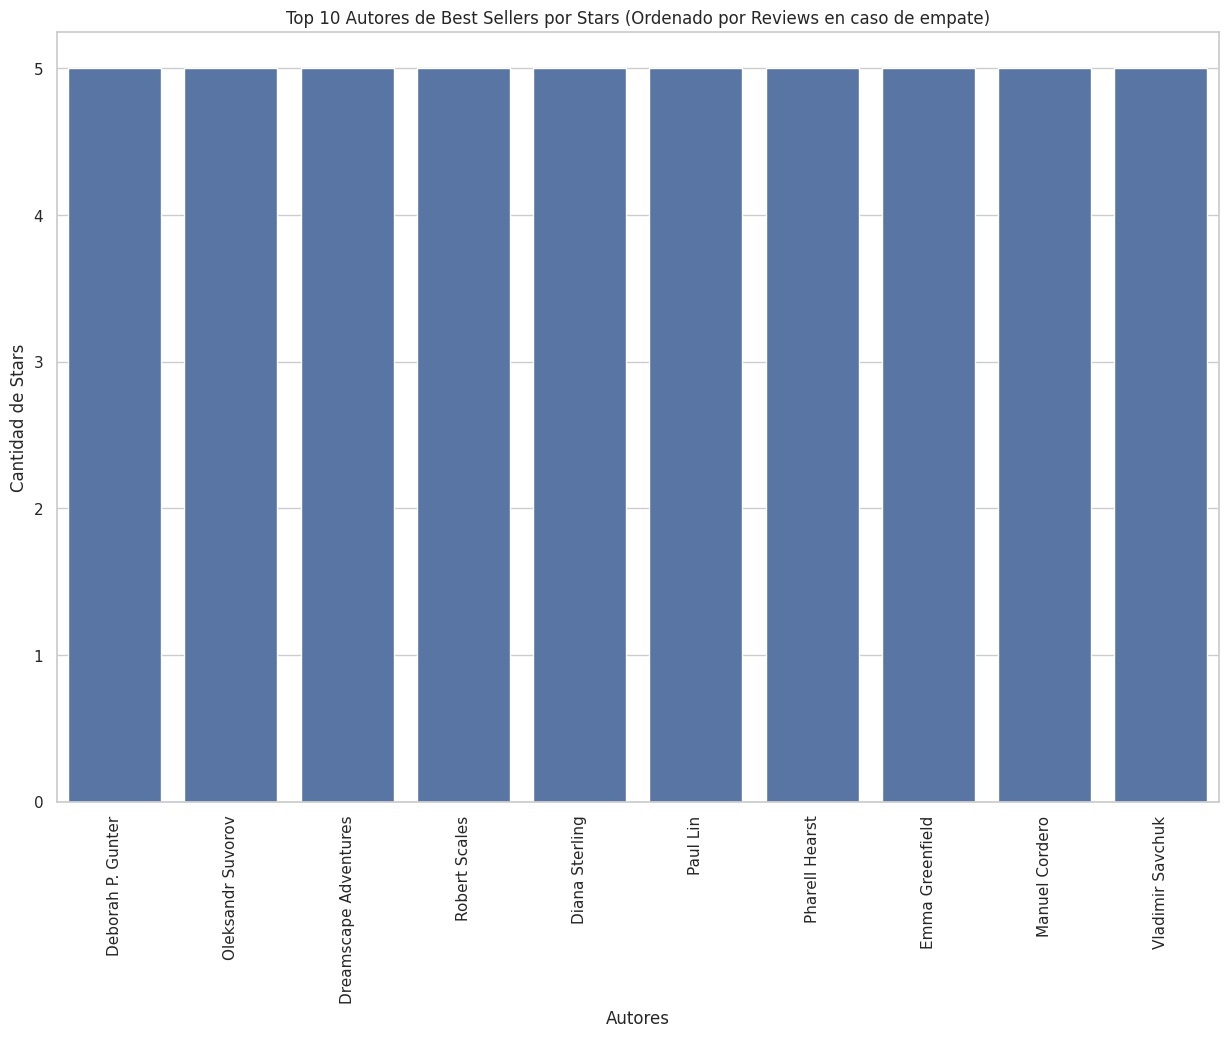




